In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, maximum_filter
from scipy.interpolate import UnivariateSpline
from scipy.spatial import cKDTree
import os
import pandas as pd


# load the .npz scan file

In [2]:
import numpy as np

data = np.load("/Users/administrateur/Desktop/projects_repo/dossier sans titre/real_data/positif/real_data_00021.npz")

print(data.files)  # shows array names inside


['data']


In [3]:
array = data.files[0]  
array_sample = data[array]  # access the array using its name
print(array_sample.shape)
print(array_sample.dtype)

(1010, 1170, 4)
float16


In [4]:
test=data[array]
rows = np.any(~np.isnan(test), axis=1)
cols = np.any(~np.isnan(test), axis=0)

rmin, rmax = np.where(rows)[0][[0, -1]]
cmin, cmax = np.where(cols)[0][[0, -1]]

cropped = test[rmin:rmax+1, cmin:cmax+1]
# Use the blue channel
img = cropped[:, :, 1]

# centerline creation logic

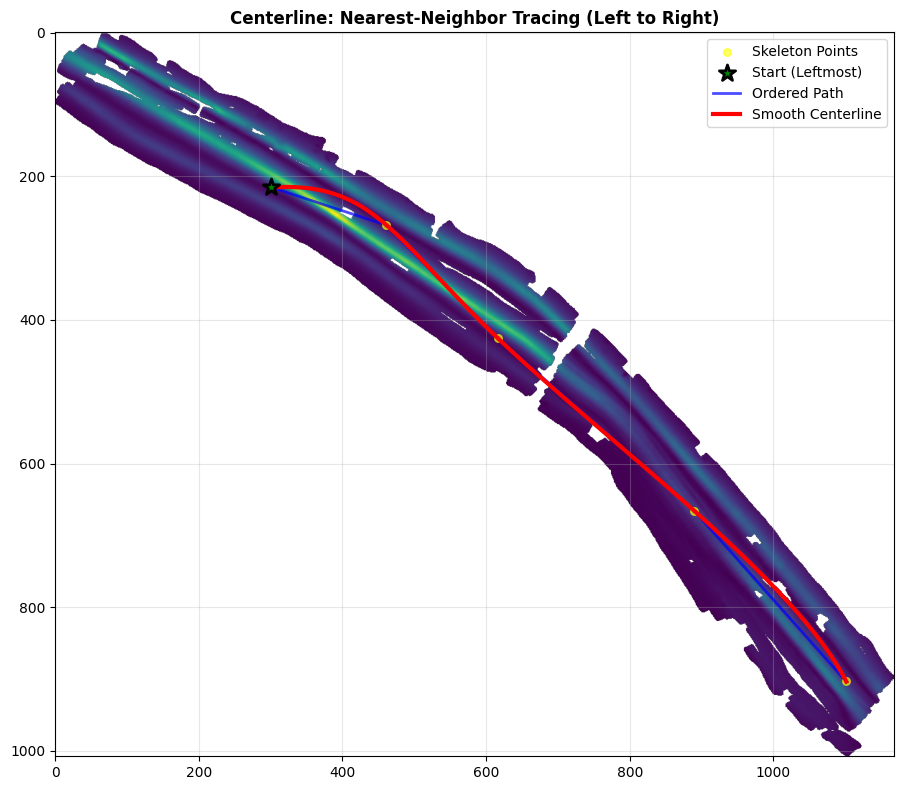

In [5]:
def create_centerline(img, max_filter_size=100, visualize=False):
   
    # Extract skeleton points
    img_mask = ~np.isnan(img)
    dist = distance_transform_edt(img_mask)
    
    # Check if image is square or nearly square (aspect ratio close to 1)
    h, w = img.shape
    aspect_ratio = max(h, w) / min(h, w)
    is_square = aspect_ratio < 1.2  # If aspect ratio is less than 1.3, treat as square
    
    if is_square and h <1000:
        print(f"Square/nearly-square image detected (aspect ratio: {aspect_ratio:.2f})")
        # For square images, use a much smaller filter to get edge points instead of center dot
        max_filter_size = max(1, min(h, w) // 8)
        if max_filter_size % 2 == 0:
            max_filter_size = 3
        print(f"Adjusted filter size for square image: {max_filter_size}")
    else:
        # Ensure filter size is odd
        
        if max_filter_size % 2 == 0:
            max_filter_size += 1
    
    skeleton_mask = (dist > 0) & img_mask & (dist == maximum_filter(dist, size=max_filter_size))
    ys_skel, xs_skel = np.where(skeleton_mask)
    
    #print(f"Skeleton points: {len(xs_skel)}")
    
    result = {
        'xs_smooth': np.array([]),
        'ys_smooth': np.array([]),
        'xs_ordered': np.array([]),
        'ys_ordered': np.array([]),
        'xs_skel': xs_skel,
        'ys_skel': ys_skel,
        'success': False
    }
    
    if len(xs_skel) <= 2:
        print("ERROR: Not enough skeleton points")
        return result
    
    # Order skeleton points using nearest-neighbor with KDTree
    points = np.column_stack([xs_skel, ys_skel])
    tree = cKDTree(points)
    
    # Start from leftmost point
    start_idx = np.argmin(xs_skel)
    ordered = [points[start_idx]]
    visited = {start_idx}
    
    # Greedily connect nearest unvisited neighbors
    while len(visited) < len(points):
        current = ordered[-1]
        _, unvisited_idx = tree.query(current, k=len(points))
        for idx in unvisited_idx:
            if idx not in visited:
                ordered.append(points[idx])
                visited.add(idx)
                break
    
    ordered = np.array(ordered)
    xs_ordered = ordered[:, 0]
    ys_ordered = ordered[:, 1]
    
    # Smooth the centerline
    try:
        t = np.linspace(0, 1, len(ordered))
        spl_x = UnivariateSpline(t, xs_ordered, s=15, k=min(3, len(ordered)-1))
        spl_y = UnivariateSpline(t, ys_ordered, s=15, k=min(3, len(ordered)-1))
        t_smooth = np.linspace(0, 1, 300)
        xs_smooth = spl_x(t_smooth)
        ys_smooth = spl_y(t_smooth)
    except:
        xs_smooth = xs_ordered
        ys_smooth = ys_ordered
    
    # Update result dictionary
    result['xs_smooth'] = xs_smooth
    result['ys_smooth'] = ys_smooth
    result['xs_ordered'] = xs_ordered
    result['ys_ordered'] = ys_ordered
    result['success'] = True
    
    # Visualization if requested
    if visualize:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img, cmap='viridis')
        ax.scatter(xs_skel, ys_skel, c='yellow', s=30, alpha=0.6, label='Skeleton Points', zorder=3)
        ax.scatter([xs_skel[start_idx]], [ys_skel[start_idx]], c='green', s=150, marker='*', 
                   label='Start (Leftmost)', zorder=5, edgecolors='black', linewidths=2)
        ax.plot(xs_ordered, ys_ordered, 'b-', linewidth=2, label='Ordered Path', alpha=0.7, zorder=2)
        ax.plot(xs_smooth, ys_smooth, 'r-', linewidth=3, label='Smooth Centerline', zorder=4)
        ax.set_title('Centerline: Nearest-Neighbor Tracing (Left to Right)', fontweight='bold', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    #print(f"✓ Centerline traced starting from leftmost point (x={xs_skel[start_idx]:.0f})")
    #print(f"✓ Smooth centerline: {len(xs_smooth)} points")
    
    return result

# Calculate max_filter_size as 1/5 of the height of the scan
max_filter_size = max(1, int(img.shape[0] / 5))
# Example usage: create centerline with visualization
centerline = create_centerline(img, max_filter_size=max_filter_size, visualize=True)
# Access the smooth centerline
xs_smooth = centerline['xs_smooth']
ys_smooth = centerline['ys_smooth']

# width calculation logic

In [6]:
def compute_width_along_centerline(img: np.ndarray, xs_center: np.ndarray, ys_center: np.ndarray, mask: np.ndarray | None = None):

   


    img = np.asarray(img)

    xs_center = np.asarray(xs_center)

    ys_center = np.asarray(ys_center)




    if mask is None:

        mask = ~np.isnan(img)

    else:

        mask = np.asarray(mask, dtype=bool)


#basically enforces that they should have the same shape
    
    assert img.shape == mask.shape, "img and mask must have same shape"

    assert xs_center.shape == ys_center.shape, "xs_center and ys_center must have same shape"



    h, w = img.shape

    n = xs_center.size

    widths = np.zeros(n, dtype=float)



    # Helper to get local tangent

    dxs = np.gradient(xs_center.astype(float))

    dys = np.gradient(ys_center.astype(float))



    for i in range(n):

        x0 = float(xs_center[i])

        y0 = float(ys_center[i])



        # Local tangent (dx, dy); normal is perpendicular to this

        dx = dxs[i]

        dy = dys[i]

        # If tangent is not valid, skip

        if dx == 0 and dy == 0:

            widths[i] = np.nan

            continue



        # Normal vector (nx, ny) perpendicular to (dx, dy)

        nx = -dy

        ny = dx

        norm = np.hypot(nx, ny)

        if norm == 0:

            widths[i] = np.nan

            continue

        nx /= norm

        ny /= norm



        # March along normal in + and - directions until leaving mask

        def walk(sign: int) -> float:

            t = 0.0

            step = 0.5  

            while True:

                t += step

                x = int(round(x0 + sign * t * nx))

                y = int(round(y0 + sign * t * ny))

                if x < 0 or x >= w or y < 0 or y >= h:

                    return (t - step)

                if not mask[y, x]:

                    return (t - step)



        t_plus = walk(+1)

        t_minus = walk(-1)



        # get total width as sum of both sides, sometimes better accuracy than just 2*t_plus or 2*t_minus 

        widths[i] = t_plus + t_minus



    return widths


def analyze_widths(img: np.ndarray, xs_center: np.ndarray, ys_center: np.ndarray, 
                   pixel_to_meter: float = 0.2, rounding_precision: int = 1):
    
    result = {
        'widths': np.array([]),
        'valid_widths': np.array([]),
        'rounded': np.array([]),
        'most_recurring_width_px': None,
        'most_recurring_width_m': None,
        'success': False
    }
    
    # Compute widths
    mask = ~np.isnan(img)
    widths = compute_width_along_centerline(img, xs_center, ys_center, mask=mask)
    result['widths'] = widths
    
    # Remove NaNs and round
    valid_widths = widths[~np.isnan(widths)]
    result['valid_widths'] = valid_widths
    
    rounded = np.round(valid_widths, rounding_precision)
    result['rounded'] = rounded
    
    if rounded.size > 0:
        # Find the most frequent value
        values, counts = np.unique(rounded, return_counts=True)
        most_recurring_width_px = values[np.argmax(counts)]
        most_recurring_width_m = most_recurring_width_px * pixel_to_meter
        
        result['most_recurring_width_px'] = most_recurring_width_px
        result['most_recurring_width_m'] = most_recurring_width_m
        result['success'] = True
        
        #print(f"Most recurring width (pixels): {most_recurring_width_px}")
        print(f"Most recurring width (meters): {most_recurring_width_m:.2f}")
    else:
        print("No valid widths computed")
    
    return result


# Call the function
width_analysis = analyze_widths(img, xs_smooth, ys_smooth, pixel_to_meter=0.2, rounding_precision=1)


Most recurring width (meters): 26.40


# loop through a folder of scans and plot the centerlines


Square/nearly-square image detected (aspect ratio: 1.02)
Adjusted filter size for square image: 55
Square/nearly-square image detected (aspect ratio: 1.03)
Adjusted filter size for square image: 3
⚠ File not found: real_data_00005.npz
Square/nearly-square image detected (aspect ratio: 1.16)
Adjusted filter size for square image: 33
Square/nearly-square image detected (aspect ratio: 1.14)
Adjusted filter size for square image: 103
Square/nearly-square image detected (aspect ratio: 1.07)
Adjusted filter size for square image: 3
ERROR: Not enough skeleton points
Square/nearly-square image detected (aspect ratio: 1.18)
Adjusted filter size for square image: 35
Square/nearly-square image detected (aspect ratio: 1.09)
Adjusted filter size for square image: 37
Square/nearly-square image detected (aspect ratio: 1.01)
Adjusted filter size for square image: 3
⚠ File not found: real_data_00034.npz
Square/nearly-square image detected (aspect ratio: 1.13)
Adjusted filter size for square image: 13
S

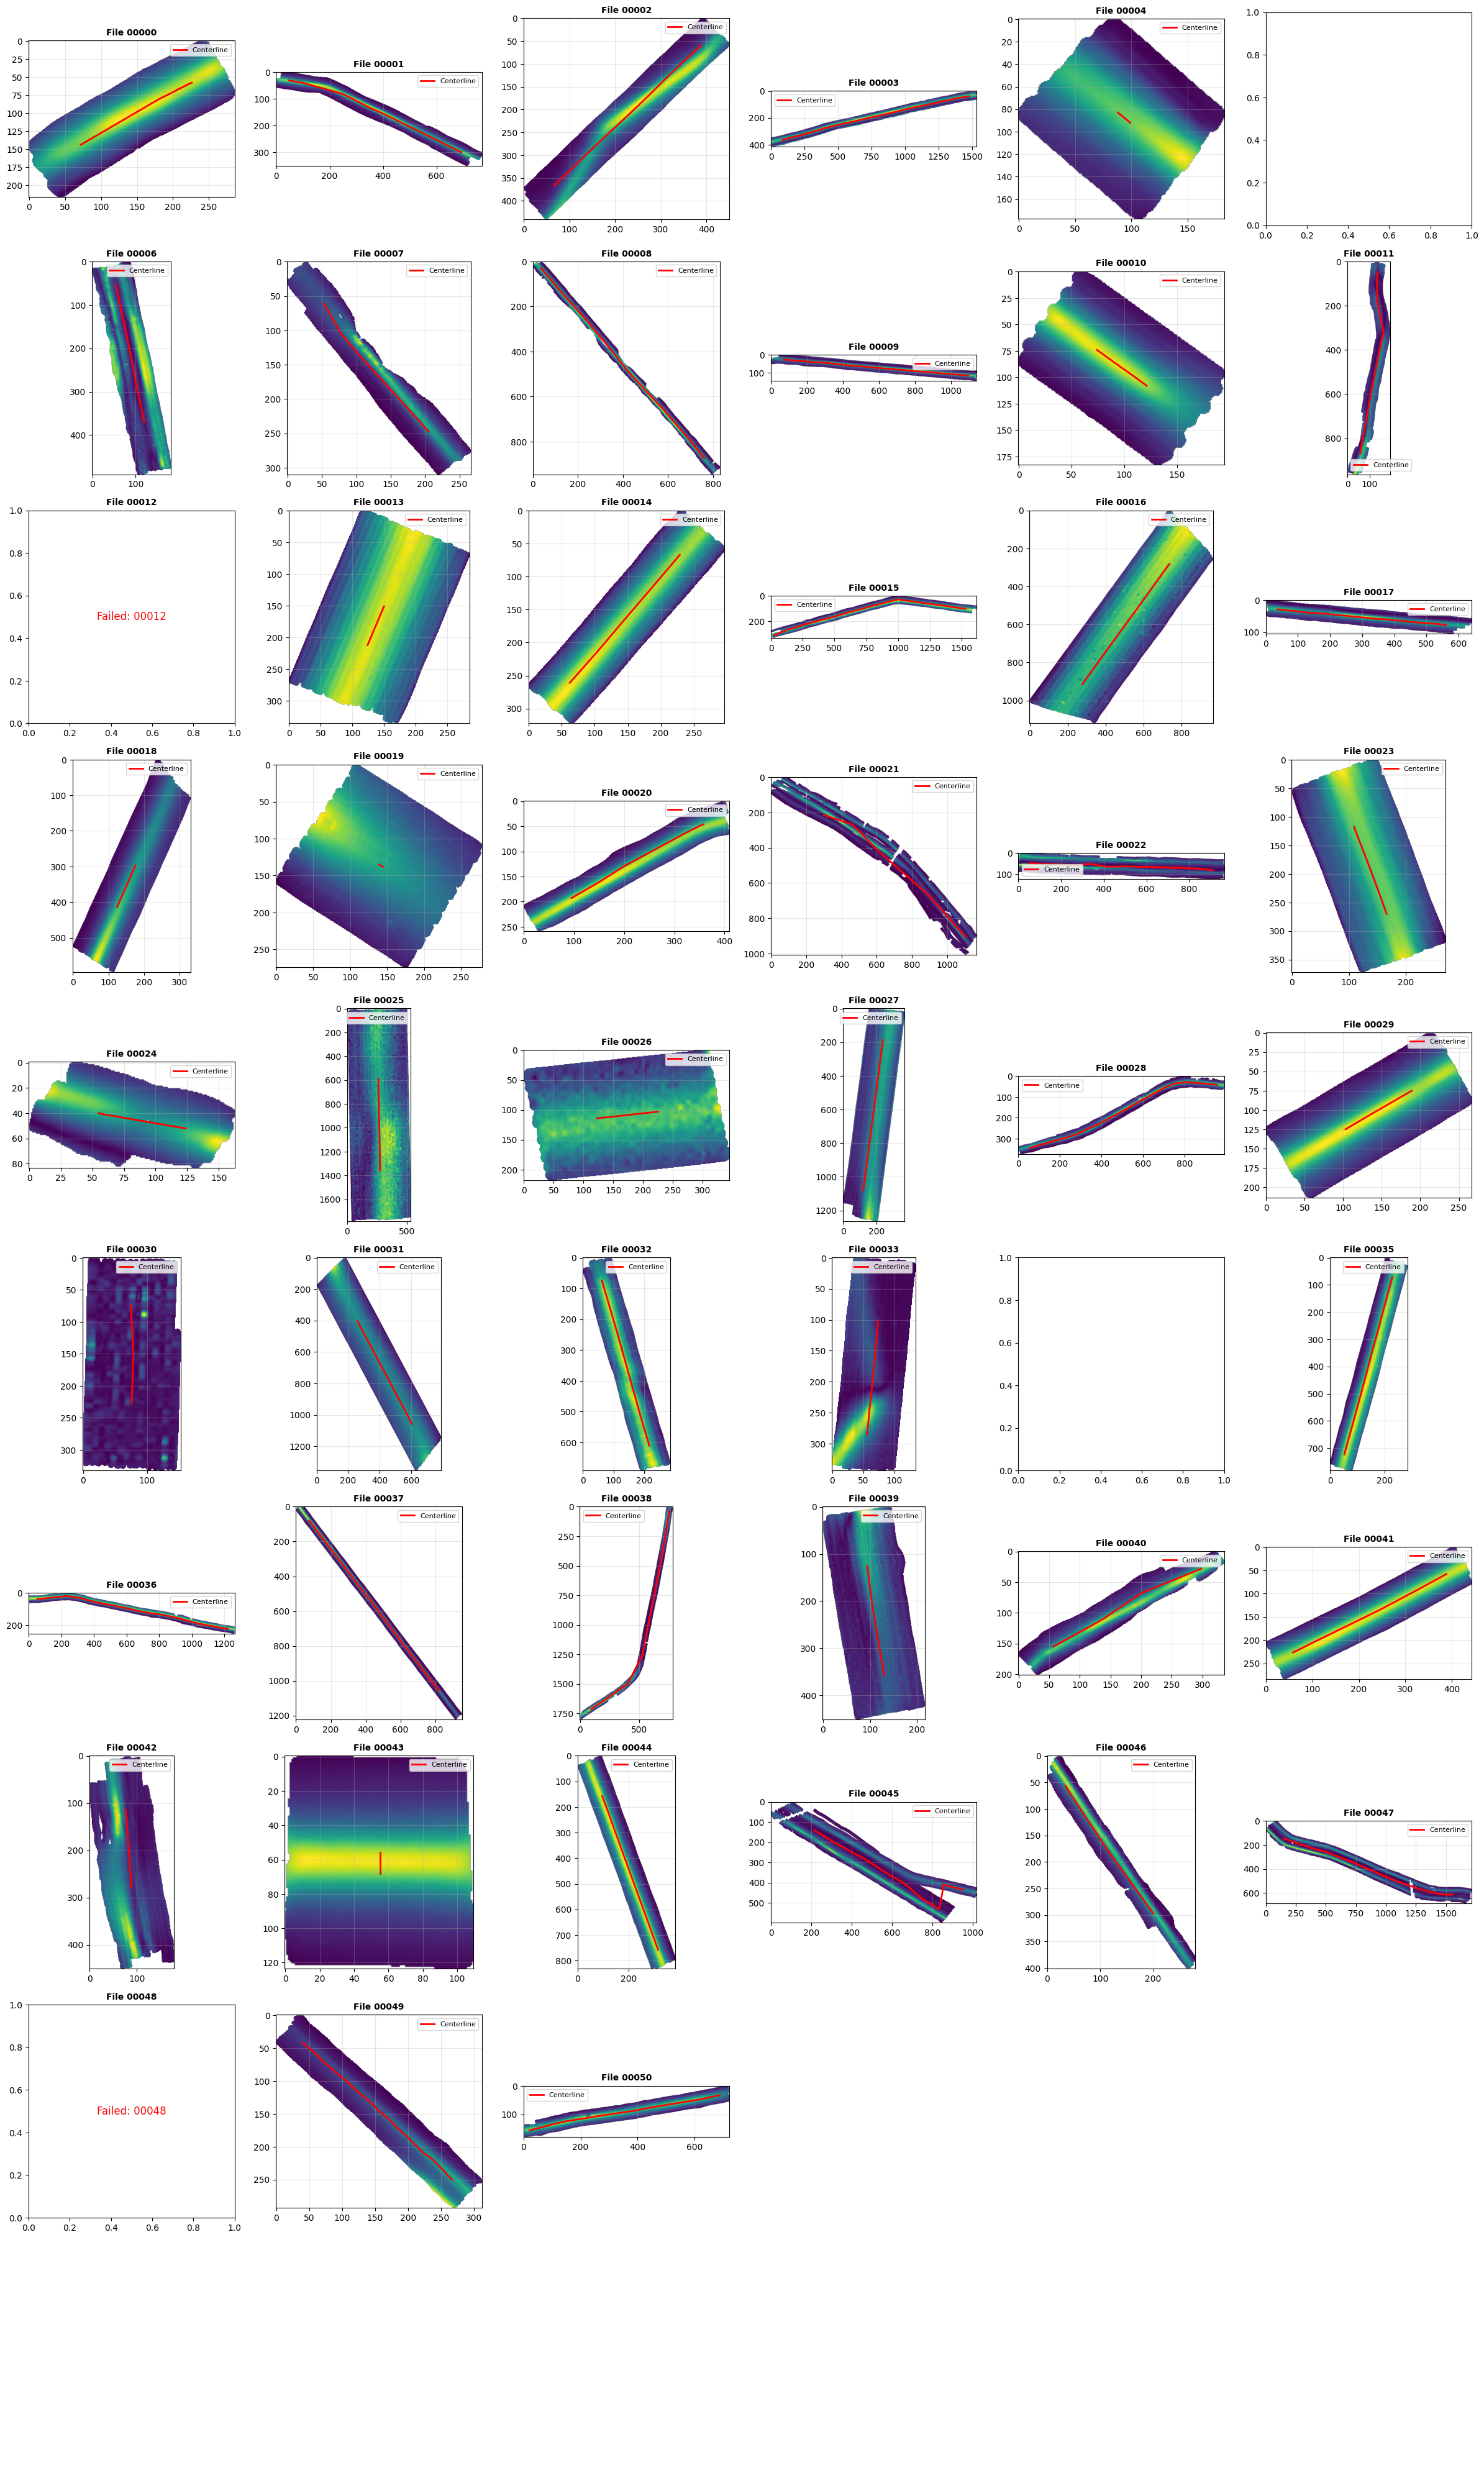

In [7]:
import os
import glob

# Define the folder path where your files are stored
data_folder = "/Users/administrateur/Desktop/projects_repo/dossier sans titre/real_data/positif"

# Create a large figure with subplots for all centerlines
fig, axes = plt.subplots(10, 6, figsize=(24, 40))
axes = axes.flatten()

# Loop through files 00000 to 00050
for file_num in range(51):
    file_name = f"real_data_{file_num:05d}.npz"
    file_path = os.path.join(data_folder, file_name)
    
    if not os.path.exists(file_path):
        print(f"⚠ File not found: {file_name}")
        continue
    
    try:
        # Load the data
        data = np.load(file_path)
        array_name = data.files[0]
        array_sample = data[array_name]
        
        # Crop the array
        rows = np.any(~np.isnan(array_sample), axis=1)
        cols = np.any(~np.isnan(array_sample), axis=0)
        
        if np.sum(rows) == 0 or np.sum(cols) == 0:
            print(f"⚠ File {file_name}: No valid data after cropping")
            continue
        
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        
        cropped = array_sample[rmin:rmax+1, cmin:cmax+1]
        img_current = cropped[:, :, 1]  # Use the blue channel
        
        # Calculate max_filter_size as 1/5 of the height of the scan
        max_filter_size = max(1, int(img_current.shape[0] / 5))
        
        # Create centerline
        centerline_current = create_centerline(img_current, max_filter_size=max_filter_size, visualize=False)
        
        if centerline_current['success']:
            xs_current = centerline_current['xs_ordered']
            ys_current = centerline_current['ys_ordered']
            
            # Plot on the subplot
            ax = axes[file_num]
            ax.imshow(img_current, cmap='viridis')
            ax.plot(xs_current, ys_current, 'r-', linewidth=2, label='Centerline')
            ax.set_title(f'File {file_num:05d}', fontsize=10, fontweight='bold')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        else:
            ax = axes[file_num]
            ax.text(0.5, 0.5, f'Failed: {file_num:05d}', 
                   transform=ax.transAxes, ha='center', va='center', fontsize=12, color='red')
            ax.set_title(f'File {file_num:05d}', fontsize=10, fontweight='bold')
    
    except Exception as e:
        print(f"✗ Error processing {file_name}: {str(e)}")
        ax = axes[file_num]
        ax.text(0.5, 0.5, f'Error: {file_num:05d}', 
               transform=ax.transAxes, ha='center', va='center', fontsize=12, color='red')
        ax.set_title(f'File {file_num:05d}', fontsize=10, fontweight='bold')

# Hide any unused subplots
for idx in range(51, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('/Users/administrateur/Desktop/projects_repo/Skipper_NDT/all_centerlines.png', dpi=100, bbox_inches='tight')
print("✓ All centerlines plotted and saved!")
plt.show()


# loop through a folder of scans and compare width with ground truth

Most recurring width (meters): 18.70
✓ File real_data_00000.npz: Ground truth = 18.1 m, Predicted = 18.70 m
Most recurring width (meters): 14.70
✓ File real_data_00001.npz: Ground truth = 12.99 m, Predicted = 14.70 m
Square/nearly-square image detected (aspect ratio: 1.02)
Adjusted filter size for square image: 55
Most recurring width (meters): 17.20
✓ File real_data_00002.npz: Ground truth = 16.96 m, Predicted = 17.20 m
Most recurring width (meters): 13.90
✓ File real_data_00003.npz: Ground truth = 13.65 m, Predicted = 13.90 m
Square/nearly-square image detected (aspect ratio: 1.03)
Adjusted filter size for square image: 3
Most recurring width (meters): 25.30
✓ File real_data_00004.npz: Ground truth = 25.3 m, Predicted = 25.30 m
⚠ File not found: real_data_00005.npz
Most recurring width (meters): 17.60
✓ File real_data_00006.npz: Ground truth = 17.57 m, Predicted = 17.60 m
Square/nearly-square image detected (aspect ratio: 1.16)
Adjusted filter size for square image: 33
Most recurring

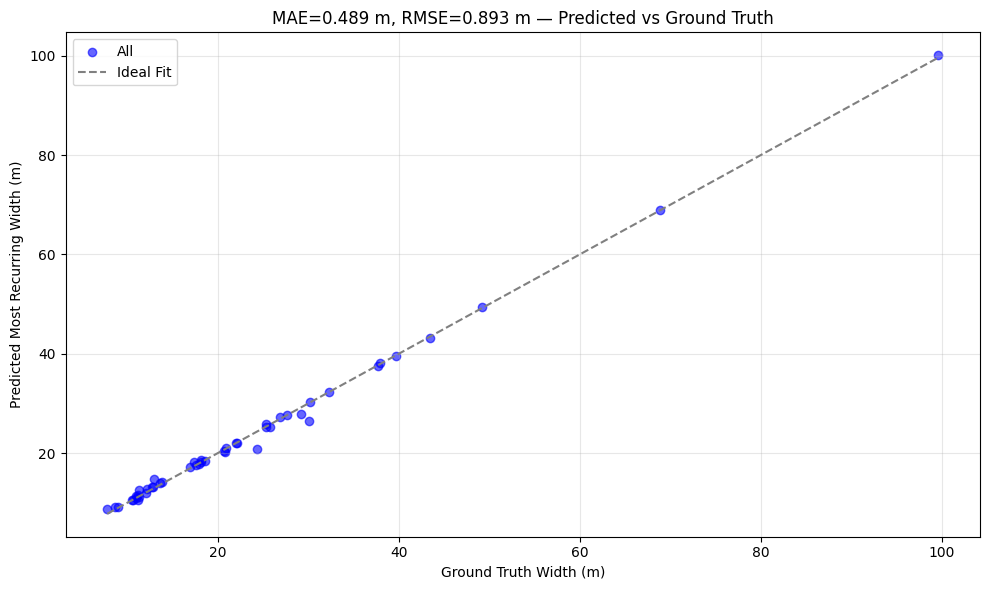


Files with absolute error > 3 m:
  - real_data_00021.npz: error = 3.66 m
  - real_data_00043.npz: error = 3.48 m


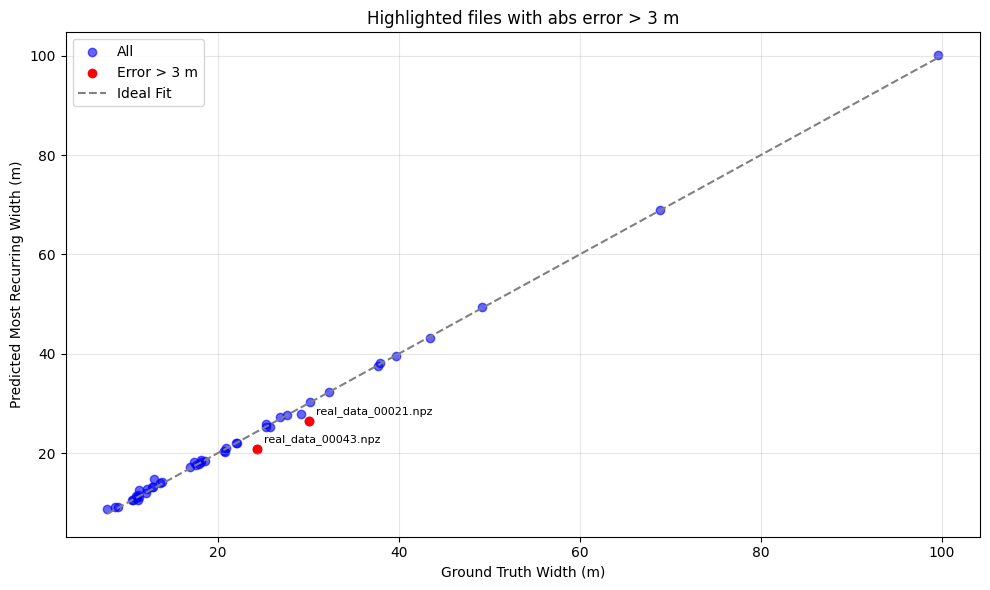


Plotting individual high-error scans:


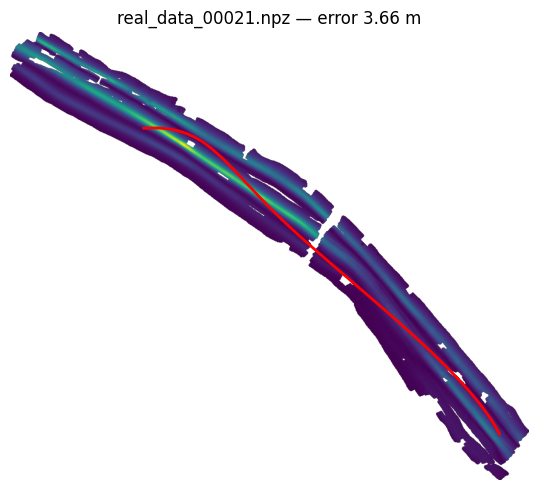

Square/nearly-square image detected (aspect ratio: 1.13)
Adjusted filter size for square image: 13


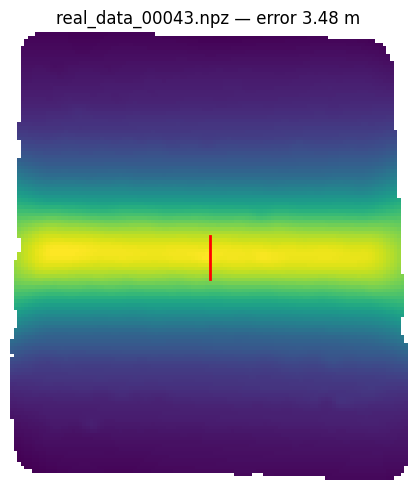

In [11]:

# ── Helpers ────────────────────────────────────────────────────────────────

def load_and_crop_image(file_path):
    """Load a .npz file, crop NaN borders, and return the blue channel (channel 1).
    Returns (img, error_msg). img is None on failure."""
    data = np.load(file_path)
    arr = data[data.files[0]]
    rows = np.any(~np.isnan(arr), axis=1)
    cols = np.any(~np.isnan(arr), axis=0)
    if np.sum(rows) == 0 or np.sum(cols) == 0:
        return None, "no_valid_data"
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = arr[rmin:rmax + 1, cmin:cmax + 1]
    return cropped[:, :, 1], None


def get_centerline_xy(centerline):
    """Return (xs, ys) preferring the smooth centerline, falling back to ordered."""
    xs = centerline.get("xs_smooth")
    ys = centerline.get("ys_smooth")
    if xs is None or len(xs) == 0:
        xs = centerline.get("xs_ordered")
        ys = centerline.get("ys_ordered")
    return xs, ys


def plot_scatter(gt, pred, title, mae=None, rmse=None,
                 highlight_gt=None, highlight_pred=None, highlight_labels=None):
    """Scatter plot of predicted vs ground-truth widths.
    Optionally highlights a subset of points with annotations."""
    plt.figure(figsize=(10, 6))
    plt.scatter(gt, pred, color="blue", alpha=0.6, label="All")
    if highlight_gt is not None:
        plt.scatter(highlight_gt, highlight_pred, color="red", label="Error > 3 m")
        if highlight_labels is not None:
            for x, y, lbl in zip(highlight_gt, highlight_pred, highlight_labels):
                plt.annotate(lbl, (x, y), fontsize=8, xytext=(5, 5), textcoords="offset points")
    plt.plot([gt.min(), gt.max()], [gt.min(), gt.max()], color="grey", linestyle="--", label="Ideal Fit")
    plt.xlabel("Ground Truth Width (m)")
    plt.ylabel("Predicted Most Recurring Width (m)")
    header = f"MAE={mae:.3f} m, RMSE={rmse:.3f} m — " if mae is not None else ""
    plt.title(f"{header}{title}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── Main loop ──────────────────────────────────────────────────────────────

df_labels = pd.read_csv(
    "/Users/administrateur/Desktop/projects_repo/dossier sans titre/real_data/pipe_presence_width_detection_label.csv",
    sep=";"
)
data_folder = "/Users/administrateur/Desktop/projects_repo/dossier sans titre/real_data/positif"

results_list = []

for file_num in range(51):
    file_name = f"real_data_{file_num:05d}.npz"
    file_path = os.path.join(data_folder, file_name)

    if not os.path.exists(file_path):
        print(f"⚠ File not found: {file_name}")
        continue

    try:
        img_current, err = load_and_crop_image(file_path)
        if img_current is None:
            print(f"⚠ File {file_name}: No valid data after cropping")
            results_list.append({"file_name": file_name, "ground_truth_width_m": None,
                                  "predicted_most_recurring_width_m": np.nan,
                                  "success": False, "error": err})
            continue

        label_row = df_labels[df_labels["field_file"] == file_name]
        width_m = label_row["width_m"].values[0] if not label_row.empty else None

        max_filter_size = max(1, int(img_current.shape[0] / 5))
        centerline_current = create_centerline(img_current, max_filter_size=max_filter_size, visualize=False)

        if not centerline_current["success"]:
            print(f"✗ Failed to compute centerline for {file_name}")
            results_list.append({"file_name": file_name, "ground_truth_width_m": width_m,
                                  "predicted_most_recurring_width_m": np.nan,
                                  "success": False, "error": "centerline_failed"})
            continue

        xs_c, ys_c = get_centerline_xy(centerline_current)
        width_analysis = analyze_widths(img_current, xs_c, ys_c, pixel_to_meter=0.2, rounding_precision=1)

        predicted_m = width_analysis.get("most_recurring_width_m") if width_analysis.get("success") else np.nan
        if width_m is not None and not np.isnan(predicted_m):
            print(f"✓ File {file_name}: Ground truth = {width_m} m, Predicted = {predicted_m:.2f} m")
        elif not width_analysis.get("success"):
            print(f"⚠ File {file_name}: width analysis failed")

        results_list.append({"file_name": file_name, "ground_truth_width_m": width_m,
                              "predicted_most_recurring_width_m": predicted_m,
                              "success": bool(width_analysis.get("success")), "error": None})

    except Exception as e:
        print(f"✗ Error processing {file_name}: {e}")
        results_list.append({"file_name": file_name, "ground_truth_width_m": None,
                              "predicted_most_recurring_width_m": np.nan,
                              "success": False, "error": str(e)})

# ── Metrics & plots ────────────────────────────────────────────────────────

df_results = pd.DataFrame(results_list) if results_list else \
    pd.DataFrame(columns=["file_name", "ground_truth_width_m", "predicted_most_recurring_width_m", "success", "error"])

valid_df = df_results.dropna(subset=["ground_truth_width_m", "predicted_most_recurring_width_m"]).copy()

if valid_df.empty:
    print("No valid (ground truth + prediction) pairs to compute MAE/RMSE or plot.")
else:
    gt   = valid_df["ground_truth_width_m"].to_numpy(dtype=float)
    pred = valid_df["predicted_most_recurring_width_m"].to_numpy(dtype=float)
    mae  = float(np.mean(np.abs(gt - pred)))
    rmse = float(np.sqrt(np.mean((gt - pred) ** 2)))
    print(f"Global MAE:  {mae:.4f} m over {gt.size} pairs")
    print(f"Global RMSE: {rmse:.4f} m over {gt.size} pairs")

    plot_scatter(gt, pred, title="Predicted vs Ground Truth", mae=mae, rmse=rmse)

    # Per-file absolute error
    df_results["abs_error_m"] = np.nan
    mask = df_results["ground_truth_width_m"].notna() & df_results["predicted_most_recurring_width_m"].notna()
    df_results.loc[mask, "abs_error_m"] = np.abs(
        df_results.loc[mask, "ground_truth_width_m"] - df_results.loc[mask, "predicted_most_recurring_width_m"]
    )

    high_err_df = df_results[df_results["abs_error_m"] > 3]
    if high_err_df.empty:
        print("\nNo files found with absolute error > 3 m.")
    else:
        print("\nFiles with absolute error > 3 m:")
        for _, row in high_err_df.iterrows():
            print(f"  - {row['file_name']}: error = {row['abs_error_m']:.2f} m")

        plot_scatter(
            gt, pred, title="Highlighted files with abs error > 3 m",
            highlight_gt=high_err_df["ground_truth_width_m"].to_numpy(dtype=float),
            highlight_pred=high_err_df["predicted_most_recurring_width_m"].to_numpy(dtype=float),
            highlight_labels=high_err_df["file_name"].tolist(),
        )

        # Individual high-error scan plots
        print("\nPlotting individual high-error scans:")
        for _, row in high_err_df.iterrows():
            fp = os.path.join(data_folder, row["file_name"])
            if not os.path.exists(fp):
                print(f"  - {row['file_name']}: file not found")
                continue
            try:
                img, err = load_and_crop_image(fp)
                if img is None:
                    print(f"  - {row['file_name']}: no valid data after cropping")
                    continue
                centerline = create_centerline(img, max_filter_size=max(1, int(img.shape[0] / 5)), visualize=False)
                plt.figure(figsize=(8, 5))
                plt.imshow(img, cmap="viridis")
                if centerline["success"]:
                    xs_plot, ys_plot = get_centerline_xy(centerline)
                    plt.plot(xs_plot, ys_plot, "r-", linewidth=2)
                plt.title(f"{row['file_name']} — error {row['abs_error_m']:.2f} m")
                plt.axis("off")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"  - {row['file_name']}: error during plotting: {e}")